### Learn micrograd

### 环境准备

In [6]:
import sys
print("Jupyter 当前使用的 Python 路径：")
print(sys.executable)
print("\nsite-packages 路径：")
for path in sys.path:
    if 'site-packages' in path:
        print(path)

Jupyter 当前使用的 Python 路径：
F:\anaconda\envs\tinygrad\python.exe

site-packages 路径：
F:\anaconda\envs\tinygrad\Lib\site-packages
F:\anaconda\envs\tinygrad\Lib\site-packages\win32
F:\anaconda\envs\tinygrad\Lib\site-packages\win32\lib
F:\anaconda\envs\tinygrad\Lib\site-packages\Pythonwin


- 先诊断Graphviz模块是否可用

In [1]:
import sys
print("Python解释器:", sys.executable)
print("Graphviz模块:", end=" ")
try:
    import graphviz
    print("✓ 可用")
except ImportError as e:
    print(f"✗ 错误: {e}")

Python解释器: F:\anaconda\envs\tinygrad\python.exe
Graphviz模块: ✓ 可用


In [3]:
import os
import sys
import subprocess
import platform

print("=== Graphviz 诊断报告 ===")
print(f"操作系统: {platform.system()} {platform.release()}")
print(f"Python路径: {sys.executable}")

# 1. 检查当前 PATH
print(f"\n当前 PATH 包含 Graphviz 吗?")
path_dirs = os.environ["PATH"].split(os.pathsep)
graphviz_paths = [p for p in path_dirs if "graphviz" in p.lower() or "dot" in p.lower()]
if graphviz_paths:
    for p in graphviz_paths:
        print(f"✅ 找到: {p}")
else:
    print("❌ PATH 中没有找到 Graphviz")

# 2. 查找常见安装位置
print(f"\n搜索常见 Graphviz 安装位置:")
common_paths = [
    r"C:\Program Files\Graphviz\bin",
    r"C:\Program Files (x86)\Graphviz\bin", 
    r"C:\Users\{}\AppData\Local\Packages\Graphviz\bin".format(os.getenv('USERNAME')),
    r"D:\Graphviz\bin",
    r"E:\Graphviz\bin",
    r"C:\Users\Public\Graphviz\bin",
    r"C:\msys64\mingw64\bin",  # MSYS2
]

for path in common_paths:
    dot_exe = os.path.join(path, "dot.exe")
    if os.path.isfile(dot_exe):
        print(f"✅ 找到 dot.exe: {dot_exe}")
    elif os.path.isdir(path):
        print(f"📁 存在目录: {path}")

# 3. 测试 dot 命令
print(f"\n测试 'dot' 命令:")
try:
    result = subprocess.run(['dot', '-V'], capture_output=True, text=True, shell=True)
    print(f"✅ dot 命令可用: {result.stderr if result.stderr else result.stdout}")
except FileNotFoundError:
    print("❌ dot 命令未找到")

# 4. 检查 graphviz Python 包
print(f"\n检查 graphviz 包:")
try:
    import graphviz
    print(f"✅ graphviz Python 包: {graphviz.__version__}")
    # 检查后端配置
    print(f"   后端路径: {graphviz.backend.__file__}")
except ImportError as e:
    print(f"❌ 导入失败: {e}")

print(f"\n=== 诊断完成 ===")

=== Graphviz 诊断报告 ===
操作系统: Windows 11
Python路径: F:\anaconda\envs\tinygrad\python.exe

当前 PATH 包含 Graphviz 吗?
❌ PATH 中没有找到 Graphviz

搜索常见 Graphviz 安装位置:

测试 'dot' 命令:
✅ dot 命令可用: dot - graphviz version 14.1.2 (0)


检查 graphviz 包:
✅ graphviz Python 包: 0.21
   后端路径: F:\anaconda\envs\tinygrad\Lib\site-packages\graphviz\backend\__init__.py

=== 诊断完成 ===


In [2]:
import os
from graphviz import Digraph

# === 正确的 PATH 添加方式（tinygrad 环境）===
graphviz_bin = r'F:\anaconda\envs\tinygrad\Library\bin'

# 添加到 PATH
if graphviz_bin not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + graphviz_bin

print("当前添加的 Graphviz bin 路径:", graphviz_bin)
print("dot.exe 是否存在？", os.path.exists(os.path.join(graphviz_bin, 'dot.exe')))


当前添加的 Graphviz bin 路径: F:\anaconda\envs\tinygrad\Library\bin
dot.exe 是否存在？ True


### micrograd:

### forward

In [4]:
class Value:
    def __init__(self,data,_children=(),_op=''):
        self.data=data
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        return out

a = Value(2.)
b = Value(-3.)
c = Value(10.)
d = a*b+c
d
    

Value(data=4.0)

In [5]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # L->R

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 制造节点
        dot.node(name =uid,label="{data %.4f}" %(n.data,),shape='record')
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        # 连接
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

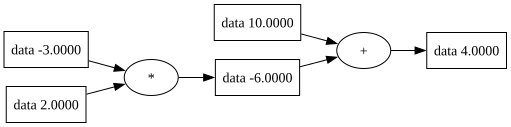

In [6]:
draw_dot(d)

### backward：
- 增加grad

- 梯度计算公式
$$\nabla_{\mathbf{x}} f = 
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}$$

$$\nabla_{\mathbf{W}} f = 
\begin{bmatrix}
\frac{\partial f}{\partial w_{11}} & \frac{\partial f}{\partial w_{12}} & \cdots & \frac{\partial f}{\partial w_{1n}} \\
\frac{\partial f}{\partial w_{21}} & \frac{\partial f}{\partial w_{22}} & \cdots & \frac{\partial f}{\partial w_{2n}} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f}{\partial w_{m1}} & \frac{\partial f}{\partial w_{m2}} & \cdots & \frac{\partial f}{\partial w_{mn}}
\end{bmatrix}$$
- 链式法则
    - non-vector
$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial u} \cdot \frac{\partial u}{\partial x}$$
    - vector
$$\frac{\partial f}{\partial x} = \sum_{i=1}^n \frac{\partial f}{\partial u_i} \frac{\partial u_i}{\partial x}$$
    - matrix
$$\frac{\partial \mathbf{y}}{\partial \mathbf{x}} = 
\frac{\partial \mathbf{y}}{\partial \mathbf{u}} \frac{\partial \mathbf{u}}{\partial \mathbf{x}} = \mathbf{J}_{\mathbf{y}}(\mathbf{u}) \mathbf{J}_{\mathbf{u}}(\mathbf{x})$$
$$\mathbf{J}_{\mathbf{f}}(\mathbf{x}) = 
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}$$

- 自动微分公式（计算图）
    - forward
$$\dot{x}_i = \sum_{j \in \text{parents}(i)} \frac{\partial x_i}{\partial x_j} \dot{x}_j$$
    - backward
$$\bar{x}_j = \sum_{i \in \text{children}(j)} \frac{\partial x_i}{\partial x_j} \bar{x}_i$$
    - graph-grad-sum
$$\frac{\partial L}{\partial v_i} = \sum_{j \in \text{children}(i)} \frac{\partial L}{\partial v_j} \frac{\partial v_j}{\partial v_i}$$

In [4]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self.grad = 0.0#----------------add
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')
        return out


In [ ]:
import matplat as plt


In [3]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # L->R

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 制造节点
        dot.node(name =uid,label="{%s|data %.4f|grad %.4f}" %(n.label,n.data,n.grad),shape='record')#-----------add
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        # 连接
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

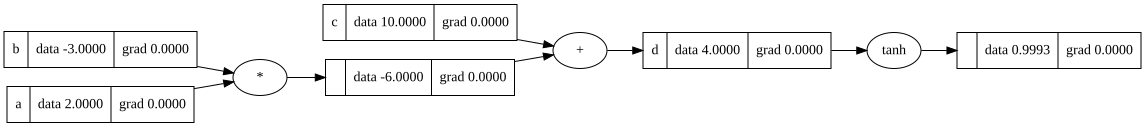

In [5]:
a = Value(2.,label='a')
b = Value(-3.,label='b')
c = Value(10.,label='c')
d = a*b+c
d.label='d'
e = d.tanh()
e.label='e'
draw_dot(e)

- 手动求导

In [16]:
# opt
def lol():
    h=0.0001
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    d = a*b+c
    d.label='d'
    L1=d.data;

    a = Value(2.+h,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    d = a*b+c
    d.label='d'
    L2=d.data;

    print((L2-L1)/h)#手动求导dd/dh
    # dd/d_=1.
    # d_/da=b
    # dd/da=dd/d_*d_/da=b

lol()

-3.000000000010772


- 自动传播

In [22]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():# 由输出节点调用，反向改变其输入节点的梯度
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out._backward = _backward # 注意，不是函数调用（），而是函数指针
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad = other.data*out.grad
            other.grad = self.data*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1.0-t**2)*out.grad
        out._backward = _backward
        return out


In [23]:
from graphviz import Digraph
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # L->R

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # 制造节点
        dot.node(name =uid,label="{%s|data %.4f|grad %.4f}" %(n.label,n.data,n.grad),shape='record')#-----------add
        if n._op:
            dot.node(name = uid+n._op,label = n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        # 连接
        dot.edge(str(id(n1)),str(id(n2))+n2._op)

    return dot

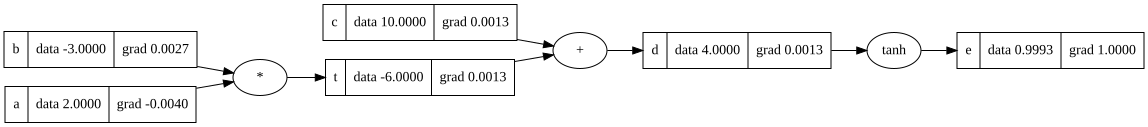

In [25]:
# opt
def lolauto():
    
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    temp =a*b
    temp.label = 't'
    d = temp+c
    d.label='d'
    e = d.tanh()
    e.label='e'
    e.grad = 1.0 # 假设
    e._backward()

    d._backward()
    c._backward()
    temp._backward()
    a._backward()
    b._backward()
    
    return e

draw_dot(lolauto())

### 拓扑排序

In [33]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

a = Value(2.,label='a')
b = Value(-3.,label='b')
c = Value(10.,label='c')
temp =a*b
temp.label = 't'
d = temp+c
d.label='d'
e = d.tanh()
e.label='e'
e.grad = 1.
build_topo(e)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=10.0),
 Value(data=4.0),
 Value(data=0.999329299739067)]

- 反向拓扑，更新梯度

In [34]:
for node in reversed(topo):
    print(node.label,node.grad)
    node._backward()

e 1.0
d 0.0013409506830258655
c 0.0013409506830258655
t 0.0013409506830258655
a -0.0040228520490775965
b 0.002681901366051731


- 整合这个自动更新到Value

In [35]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():# 由输出节点调用，反向改变其输入节点的梯度
            self.grad = 1.0*out.grad
            other.grad = 1.0*out.grad
        out._backward = _backward # 注意，不是函数调用（），而是函数指针
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad = other.data*out.grad
            other.grad = self.data*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1.0-t**2)*out.grad
        out._backward = _backward
        return out

    def backward(self):
        # 拓扑排序
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 反向更新
        for node in reversed(topo):
            node._backward()

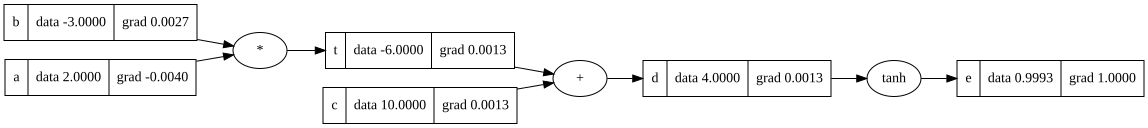

In [36]:
def lolauto():
    
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    temp =a*b
    temp.label = 't'
    d = temp+c
    d.label='d'
    e = d.tanh()
    e.label='e'
    e.grad = 1.0 # 假设
    e.backward()

    return e

draw_dot(lolauto())

### 代码现在的问题：
- 一个节点只能指向另一个节点一次（grad更新采用覆盖式）

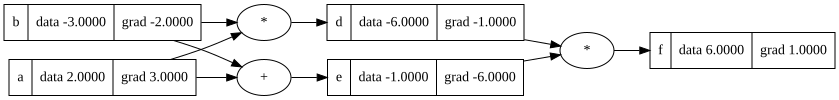

In [37]:
a = Value(2.,label='a')
b = Value(-3.,label='b')
d = a*b;d.label='d'
e = a+b;e.label='e'
f = d*e;f.label='f'

f.grad = 1.
f.backward()
draw_dot(f)

- 将设置grad改为+=

In [38]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():# 由输出节点调用，反向改变其输入节点的梯度
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward # 注意，不是函数调用（），而是函数指针
        return out

    def __mul__(self,other):
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1.0-t**2)*out.grad
        out._backward = _backward
        return out

    def backward(self):
        # 拓扑排序
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 反向更新
        for node in reversed(topo):
            node._backward()

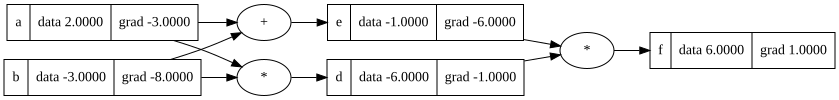

In [39]:
a = Value(2.,label='a')
b = Value(-3.,label='b')
d = a*b;d.label='d'
e = a+b;e.label='e'
f = d*e;f.label='f'

f.grad = 1.
f.backward()
draw_dot(f)

### 丰富运算

1. 解决常数问题：a+1, a*2 ?
    `other = other if isinstance(other,Value) else Value(other)`
2. 解决次序问题：1+a, 2*a ?
    定义反向运算符：`__rmul__,__radd__`
   当1+a失败后，尝试调用`a.__radd__(1) `

3. 增加函数exp
4. 增加除法:`a/b == a*(b**(-1))` 则要实现：指数
5. 负数`__neg__`，减法`__sub__`

In [114]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():# 由输出节点调用，反向改变其输入节点的梯度
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward # 注意，不是函数调用（），而是函数指针
        return out

    def __radd__(self,other):
        return self+other

    def __neg__(self):
        return self*(-1)

    def __sub__(self,other):
        return self+(-other)

    def __mul__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __truediv__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        return self*other**(-1)

    def __rtruediv__(self,other):
        return self**(-1)*other

    def __pow__(self,other):
        # 常数类型Int/float
        assert isinstance(other,(int,float)),"only int/float power permmit now!"
        out = Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad += other*self.data**(other-1)*out.grad
        out._backward = _backward
        return out

    # 2 * value?
    def __rmul__(self,other):
       return self*other

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1.0-t**2)*out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad = out.data * out.grad
        out._backward = _backward
        return out

    

    def backward(self):
        # 拓扑排序
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 反向更新
        #------ 隐式设置根节点（标量）grad为1.
        self.grad = 1.
        for node in reversed(topo):
            node._backward()

In [80]:
a = Value(2.,label='a')
b = Value(3.,label='b')
a*2
2*a
a+1
1+a
a**2
a/b
a/3
3/a

Value(data=1.5)

In [81]:
-a
a-b

Value(data=-1.0)

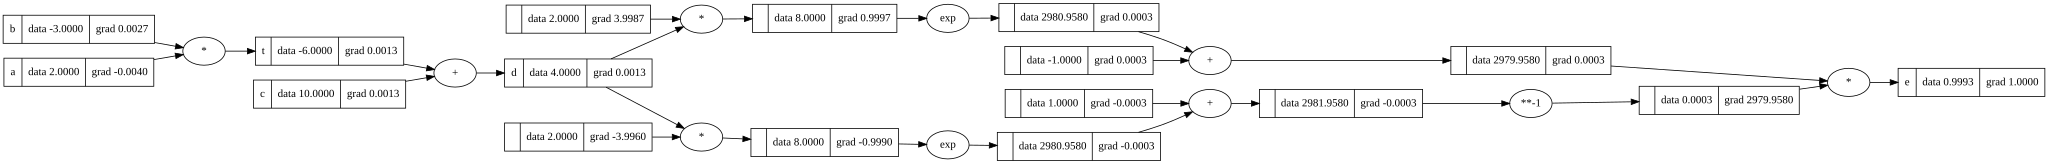

In [82]:
def lolauto():
    
    a = Value(2.,label='a')
    b = Value(-3.,label='b')
    c = Value(10.,label='c')
    temp =a*b
    temp.label = 't'
    d = temp+c
    d.label='d'
    e = ((d*2).exp()-1)/((d*2).exp()+1)
    e.label='e'
    e.grad = 1.0 # 假设
    e.backward()

    return e

draw_dot(lolauto())

### 构建网络

In [99]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w*x +b
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) ==1 else outs

class MLP:
    def __init__(self,nin,nout):
        # nout--[hidden_d1,hiddend2,...]
        sz = [nin]+nout
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nout))]

    def __call__(self,x):
        yi = x
        for L in self.layers:
            yi = L(yi)
        return yi

In [100]:
x = [2.,3.]
n = Neuron(2)
n(x)

Value(data=0.870178333450077)

In [101]:
x = [2.,3.]
L1 = Layer(2,3)
L2 = Layer(3,1)
L2(L1(x))

Value(data=0.2447854868316922)

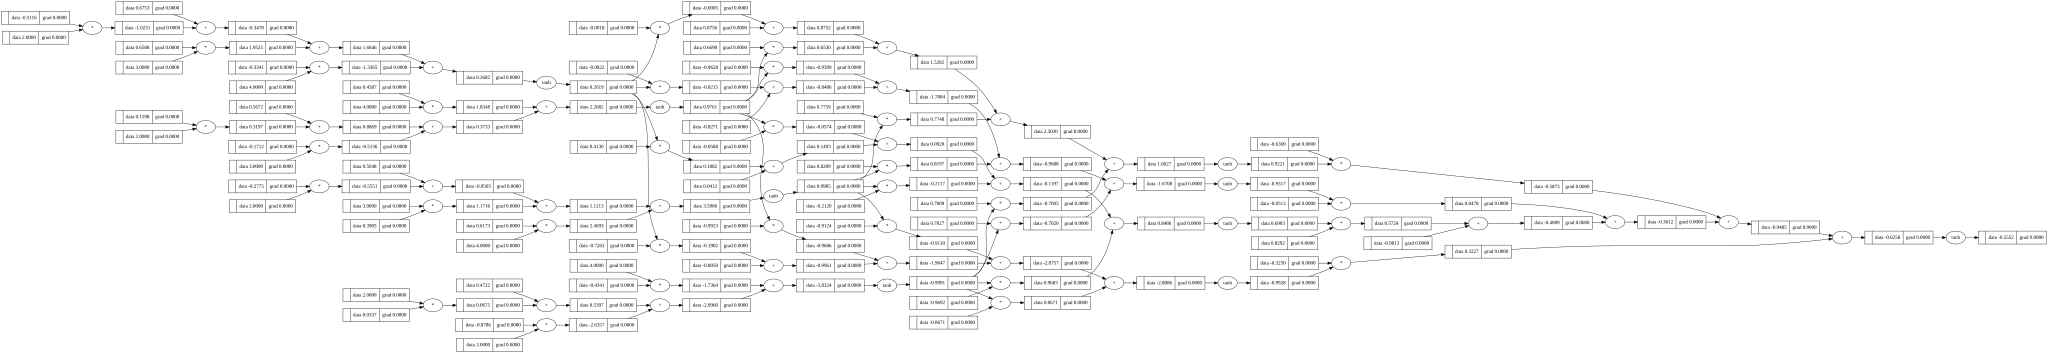

In [102]:
x = [2.,3.,4.]
mlp = MLP(3,[4,4,1])
draw_dot(mlp(x))

### loss&train

In [115]:
xs = [
    [2.,3.,-1.],
    [3.,-1.,0.5],
    [0.5,1.,1.],
    [1.,1.,-1.]
]

ys = [1.,-1.,-1.,1.]

mlp = MLP(3,[4,4,1])
ypred = [mlp(x) for x in xs]
ypred

[Value(data=-0.6484260199243369),
 Value(data=0.5921006623651993),
 Value(data=-0.8595322580628182),
 Value(data=-0.6456113892898948)]

In [116]:
loss = sum((yout - y)**2 for yout,y in zip(ypred,ys))
loss

Value(data=7.979860893352846)

In [117]:
loss.grad

0.0

In [118]:
loss.backward()# backward时隐式设置根grad=1.

In [119]:
mlp.layers[0].neurons[0].w[0].grad

-1.0871909361900616

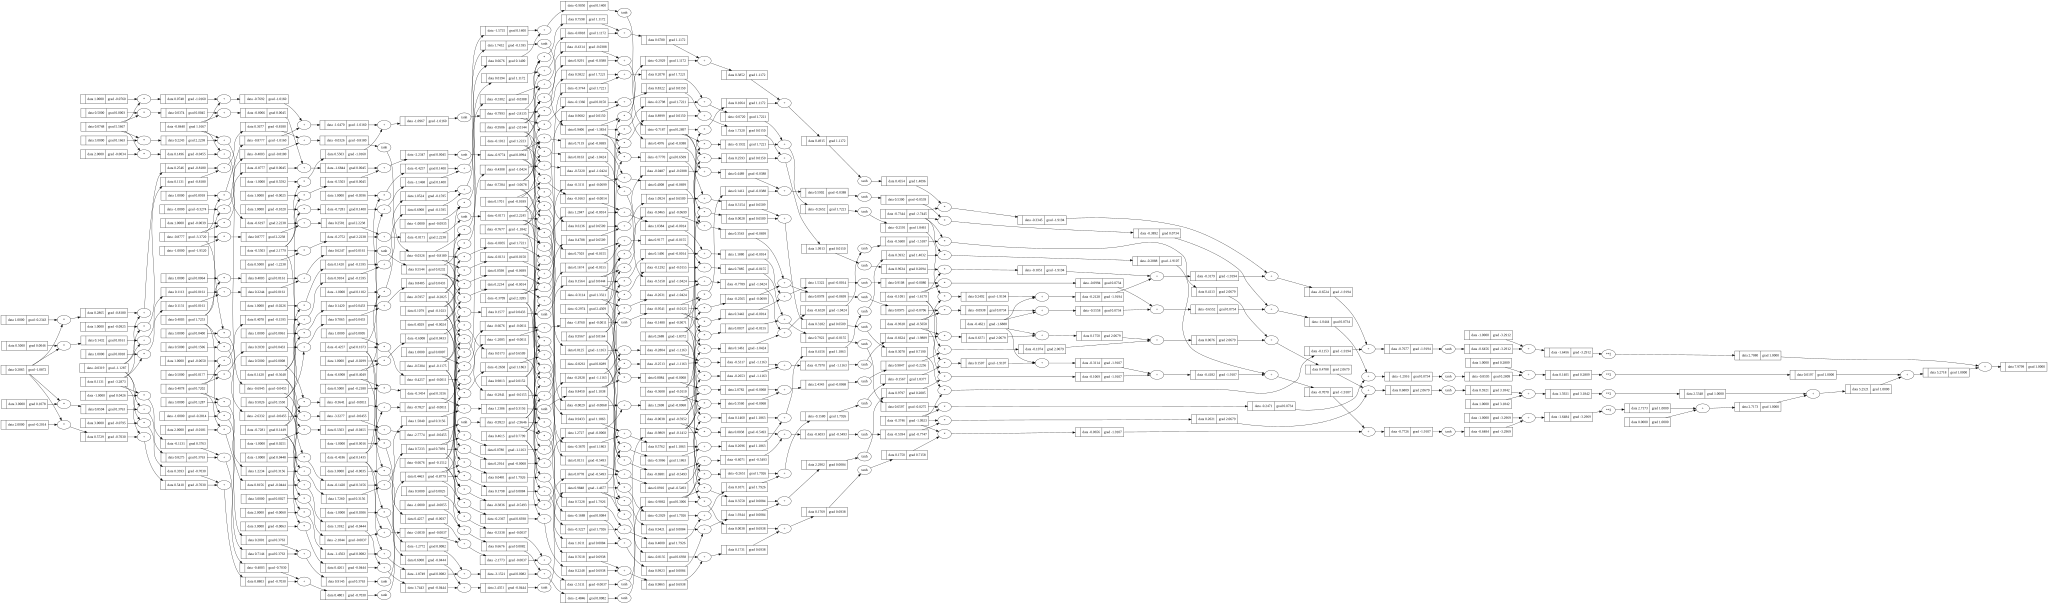

In [120]:
draw_dot(loss)

### 更新参数
- 则要获取网络参数，增量这部分api

In [123]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w*x +b
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        # [w1,w2,...wn,b]
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) ==1 else outs

    # 这种是括号括号形式[[n1_p],[n2_p],...]
    def _parameters(self):
        # [n1_para,n2_para,...]
        return [n.parameters() for n in self.neurons]

    # 拆开括号
    def parameters(self):
        # [n1_para,n2_para,...]
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self,nin,nout):
        # nout--[hidden_d1,hiddend2,...]
        sz = [nin]+nout
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nout))]

    def __call__(self,x):
        yi = x
        for L in self.layers:
            yi = L(yi)
        return yi

    def parameters(self):
        # [l1_para,l2_para,...]
        return [p for l in self.layers for p in l.parameters()]

In [131]:
xs = [
    [2.,3.,-1.],
    [3.,-1.,0.5],
    [0.5,1.,1.],
    [1.,1.,-1.]
]

ys = [1.,-1.,-1.,1.]

mlp = MLP(3,[4,4,1])
ypred = [mlp(x) for x in xs]
mlp.parameters()

[Value(data=0.40318050811393014),
 Value(data=0.9615470975419418),
 Value(data=0.9521725931398581),
 Value(data=0.5247899999513939),
 Value(data=0.3317759989421185),
 Value(data=-0.6805220522895954),
 Value(data=0.4616142398280769),
 Value(data=0.5037397725285315),
 Value(data=-0.4354035790509616),
 Value(data=0.8030586306170695),
 Value(data=0.7892298640486823),
 Value(data=-0.791637709315306),
 Value(data=-0.7096523246443689),
 Value(data=0.2612232902930056),
 Value(data=-0.8488213585383184),
 Value(data=0.5228184937451257),
 Value(data=0.0792755191443062),
 Value(data=-0.16105774896542457),
 Value(data=-0.5898360147793782),
 Value(data=0.26570814726861647),
 Value(data=-0.07051889222997088),
 Value(data=0.6736668405879276),
 Value(data=0.7993881301790631),
 Value(data=0.555519906714137),
 Value(data=0.44829150465131784),
 Value(data=-0.6778903839295563),
 Value(data=0.4403669559687253),
 Value(data=-0.8564490558939746),
 Value(data=-0.41605701256196537),
 Value(data=-0.4337734900841

- 更新参数：即加上step乘负梯度

In [129]:
# 更新参数--负梯度方向
step = 0.01
for p in mlp.parameters():
    p.data -= step*p.grad 

In [140]:
xs = [
    [2.,3.,-1.],
    [3.,-1.,0.5],
    [0.5,1.,1.],
    [1.,1.,-1.]
]

ys = [1.,-1.,-1.,1.]

mlp = MLP(3,[4,4,1])
ypred = [mlp(x) for x in xs]
loss = sum((yout - y)**2 for yout,y in zip(ypred,ys))
print(loss)

Value(data=5.986726168659322)


In [164]:
loss.backward()
# 更新参数--负梯度方向
step = 0.01
for p in mlp.parameters():
    p.data += -step*p.grad 
ypred = [mlp(x) for x in xs]
loss = sum((yout - y)**2 for yout,y in zip(ypred,ys))
print(loss)

Value(data=0.012221387659198968)


- ！！！注意：在下次反向传播前，要将梯度清零！！（由于+=）

In [165]:
# zero_grad
for p in mlp.parameters():
    p.grad = 0

## 总结

In [166]:
import math
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.label = label
        self._backward = lambda:None # 更新公式由其构成的表达式决定
        self.grad = 0.0
        self._prev=set(_children) # 子节点
        self._op=_op #构建计算图，保留操作

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')

        def _backward():# 由输出节点调用，反向改变其输入节点的梯度
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward # 注意，不是函数调用（），而是函数指针
        return out

    def __radd__(self,other):
        return self+other

    def __neg__(self):
        return self*(-1)

    def __sub__(self,other):
        return self+(-other)

    def __mul__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out

    def __truediv__(self,other):
        # 解决常数问题
        other = other if isinstance(other,Value) else Value(other)
        return self*other**(-1)

    def __rtruediv__(self,other):
        return self**(-1)*other

    def __pow__(self,other):
        # 常数类型Int/float
        assert isinstance(other,(int,float)),"only int/float power permmit now!"
        out = Value(self.data**other,(self,),f'**{other}')

        def _backward():
            self.grad += other*self.data**(other-1)*out.grad
        out._backward = _backward
        return out

    # 2 * value?
    def __rmul__(self,other):
       return self*other

    def tanh(self):
        # dtanh(x)/dx = 1-tanh(x)^2
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1.0-t**2)*out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad = out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        # 拓扑排序
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        # 反向更新
        #------ 隐式设置根节点（标量）grad为1.
        self.grad = 1.
        for node in reversed(topo):
            node._backward()

In [167]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # w*x +b
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):
        # [w1,w2,...wn,b]
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) ==1 else outs

    # 这种是括号括号形式[[n1_p],[n2_p],...]
    def _parameters(self):
        # [n1_para,n2_para,...]
        return [n.parameters() for n in self.neurons]

    # 拆开括号
    def parameters(self):
        # [n1_para,n2_para,...]
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self,nin,nout):
        # nout--[hidden_d1,hiddend2,...]
        sz = [nin]+nout
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nout))]

    def __call__(self,x):
        yi = x
        for L in self.layers:
            yi = L(yi)
        return yi

    def parameters(self):
        # [l1_para,l2_para,...]
        return [p for l in self.layers for p in l.parameters()]